In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA, FastICA

In [3]:
def compute_trial_directions_np(vel):
    """
    vel: np.ndarray of shape (n_trials, n_time_bins, 2)
        where vel[..., 0] is vx, vel[..., 1] is vy
    Returns: np.ndarray of shape (n_trials,) with direction labels (0~7)
    """
    # Step 1: 计算每个时间点的方向角
    loc = vel.cumsum(axis=1)
    angles = np.arctan2(loc[:, -1, 1], loc[:, -1, 0])  # (-π, π)

    # Step 2: 转换到 [0, 2π)
    angles = (angles + 2 * np.pi + np.pi / 8) % (2 * np.pi)

    # Step 3: 划分为 8 个方向
    direction_bins = np.floor(angles / (np.pi / 4)).astype(int) % 8

    # Step 4: 对每个 trial，统计最常出现的方向
    n_trials = vel.shape[0]
    trial_dirs = np.array([direction_bins[i] for i in range(n_trials)])

    return trial_dirs


# 示例
# vel = np.random.randn(n_trials, n_time_bins, 2)
# trial_directions = compute_trial_directions_np(vel)
# print(trial_directions)

In [5]:
x = pd.read_pickle("source_data_array.pkl")
x["direction"] = compute_trial_directions_np(x["vel"])

# non_zero_idx = x["neural"].std(axis=(0, 1)) != 0
# x["neural"] = x["neural"][:, :, non_zero_idx] / x["neural"].max()
x["neural"] = x["neural"] / x["neural"].max()
pd.to_pickle(x, "source_data_array_with_dir.pkl")

In [109]:
x.keys()
n_trials, n_time_bins, n_neurons = x["neural"].shape

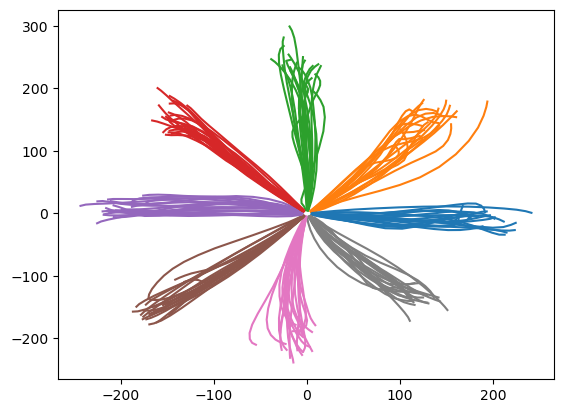

In [110]:
trial = 0

for trial in range(x["neural"].shape[0]):
    plt.plot(
        x["vel"][trial, :, 0].cumsum(),
        x["vel"][trial, :, 1].cumsum(),
        f"C{x['direction'][trial]}",
    )

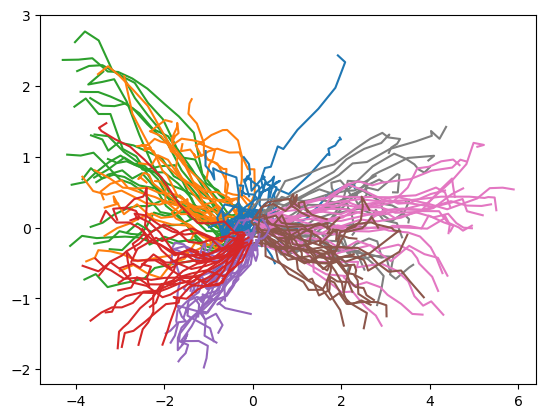

In [111]:
z = (
    PCA(n_components=2)
    .fit_transform(x["neural"].reshape(n_trials * n_time_bins, n_neurons))
    .reshape(n_trials, n_time_bins, -1)
).cumsum(axis=1)
for trial in range(n_trials):
    plt.plot(
        z[trial, :, 0],
        z[trial, :, 1],
        f"C{x['direction'][trial]}",
    )

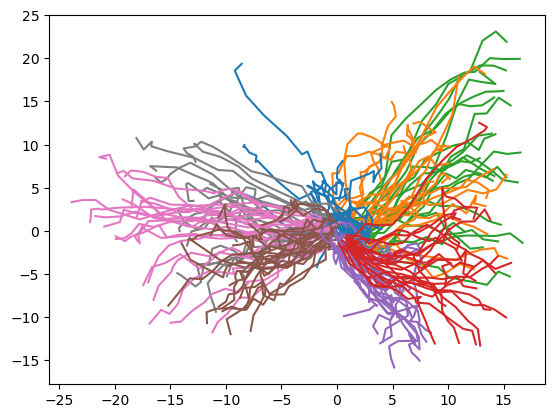

In [112]:
z = (
    FastICA(n_components=2)
    .fit_transform(x["neural"].reshape(n_trials * n_time_bins, n_neurons))
    .reshape(n_trials, n_time_bins, -1)
).cumsum(axis=1)

for trial in range(n_trials):
    plt.plot(
        z[trial, :, 0],
        z[trial, :, 1],
        f"C{x['direction'][trial]}",
    )

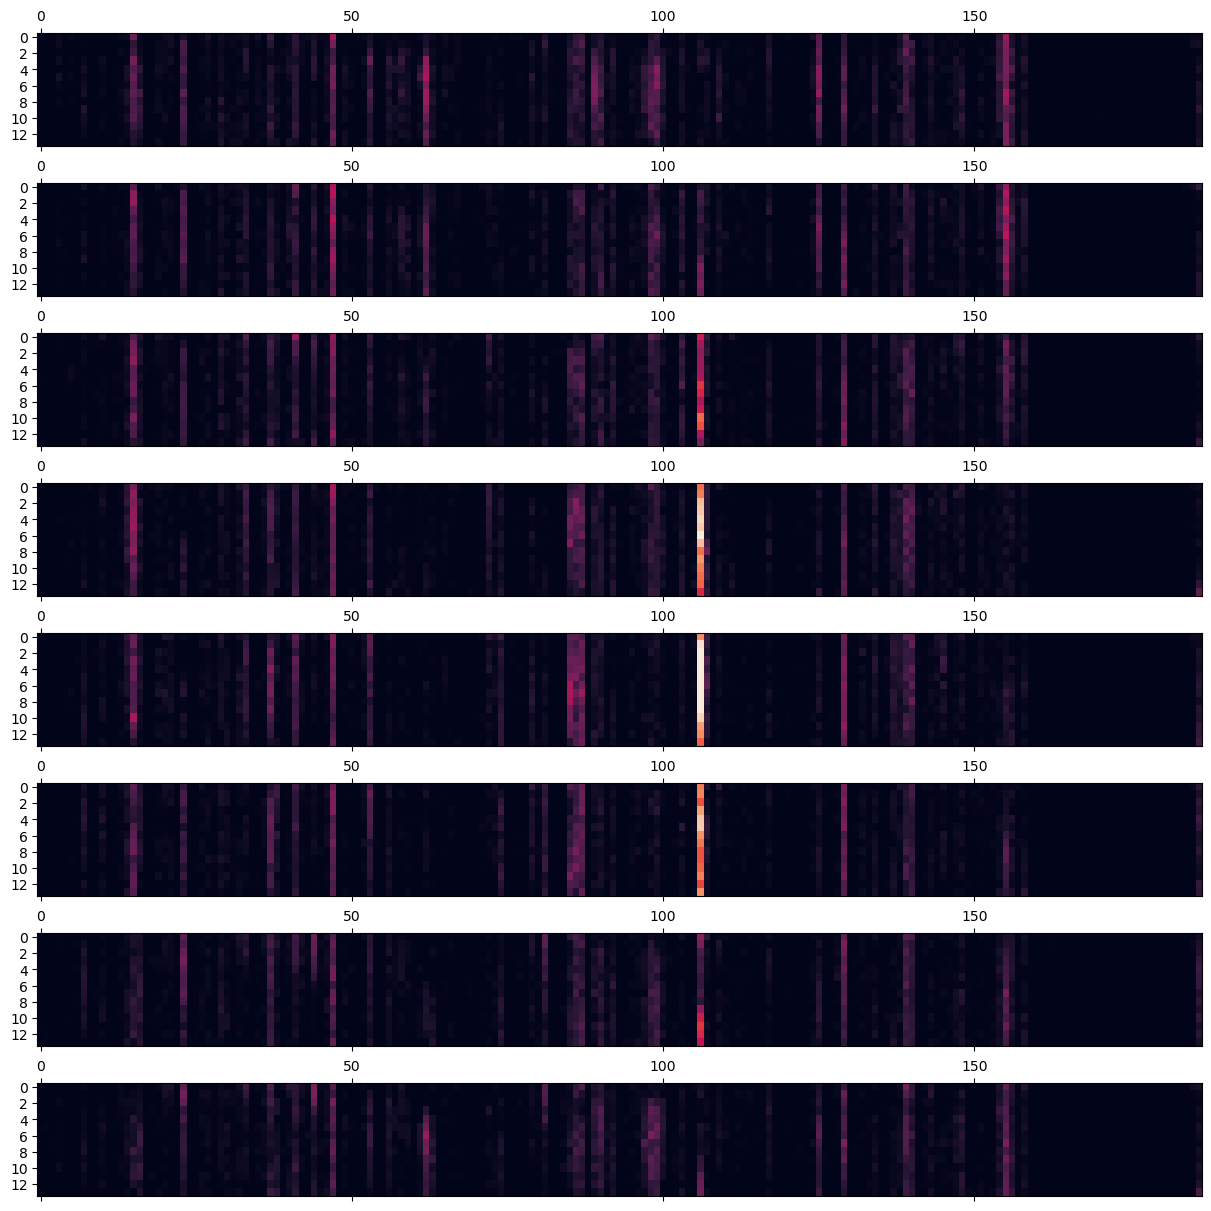

In [ ]:
fig, axs = plt.subplots(8, 1, figsize=(12, 12), layout="constrained")


for direction in range(8):
    ax = axs[direction]
    ax.matshow(
        x["neural"][x["direction"] == direction].mean(axis=0),
        aspect="auto",
        vmin=0,
        vmax=3,
        cmap="rocket",
    )

<Axes: >

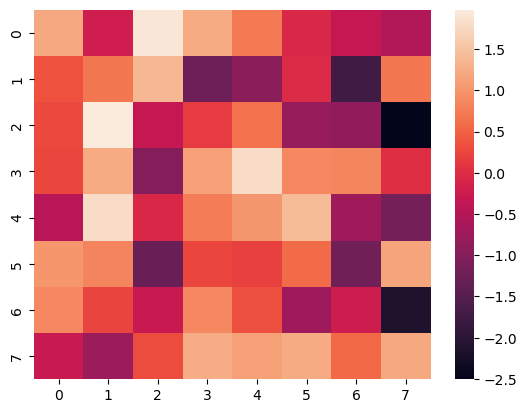

In [85]:
sns.heatmap(np.random.randn(8, 8), cmap="rocket")

In [4]:
x = pd.read_pickle("source_data_array.pkl")
x["direction"] = compute_trial_directions_np(x["vel"])

non_zero_idx = x["neural"].std(axis=(0, 1)) != 0
x["neural"] = x["neural"][:, :, non_zero_idx] / x["neural"].max()
pd.to_pickle(x, "source_data_array_with_dir_2.pkl")